In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("wine_data.csv",header=None,usecols=[0,1,2])
df.columns=['class label','alcohol','malic acid']
df.sample(10)

,class label,alcohol,malic acid
7,1,14.06,2.15
62,2,13.67,1.25
10,1,14.10,2.16
120,2,11.45,2.40
74,2,11.96,1.09
17,1,13.83,1.57
126,2,12.43,1.53
148,3,13.32,3.24
71,2,13.86,1.51
160,3,12.36,3.83


<Axes: xlabel='alcohol', ylabel='Density'>

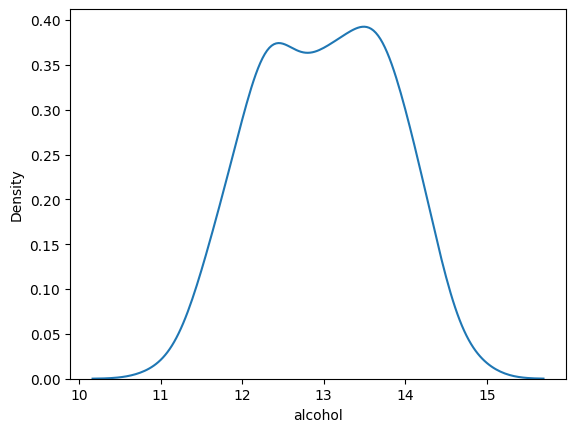

In [5]:
sns.kdeplot(df['alcohol'])

<Axes: xlabel='malic acid', ylabel='Density'>

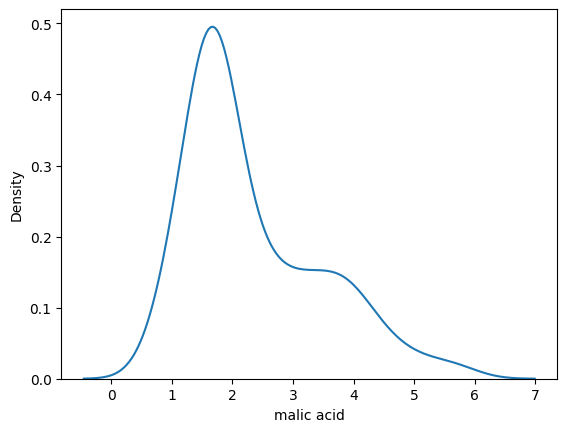

In [6]:
sns.kdeplot(df['malic acid'])

<Axes: xlabel='alcohol', ylabel='malic acid'>

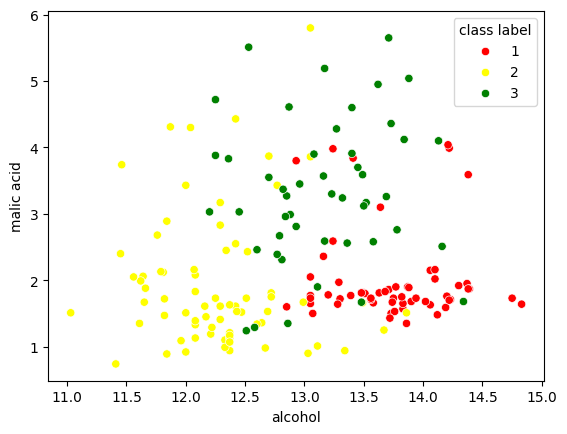

In [8]:
color_dict={1:"red",2:"yellow",3:"green"}
sns.scatterplot(x=df['alcohol'],y=df['malic acid'],hue=df["class label"],palette=color_dict)


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=["class label"]),df["class label"],test_size=0.2,random_state=0)

scaler=MinMaxScaler()
scaler.fit(x_train)
x_train_scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)

lr=LogisticRegression()
slr=LogisticRegression()

lr.fit(x_train,y_train)
pred=lr.predict(x_test)

slr.fit(x_train_scaled,y_train)
spred=slr.predict(x_test_scaled)

print("accuracy score before scaling:",accuracy_score(y_test,pred))
print("accuracy score after scaling:",accuracy_score(y_test,spred))





accuracy score before scaling: 0.7222222222222222
accuracy score after scaling: 0.75


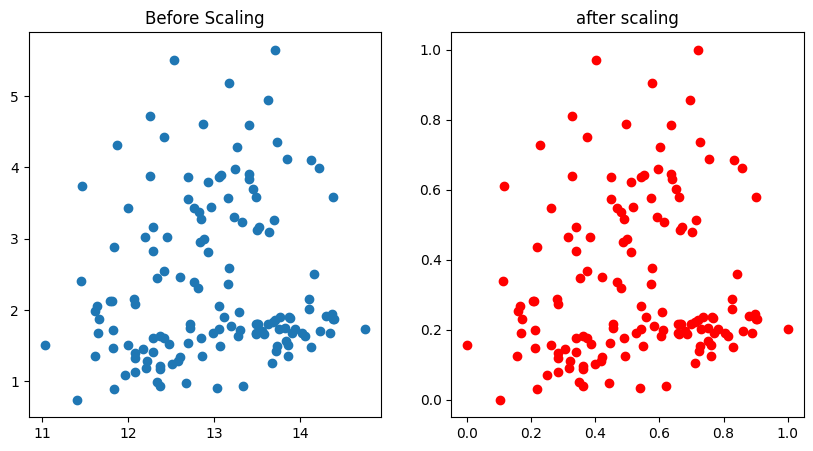

In [11]:
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(10,5))
ax1.set_title("Before Scaling")
ax1.scatter(x_train["alcohol"],x_train["malic acid"])
ax2.set_title("after scaling")
ax2.scatter(x_train_scaled["alcohol"],x_train_scaled["malic acid"],color="red")
plt.show()


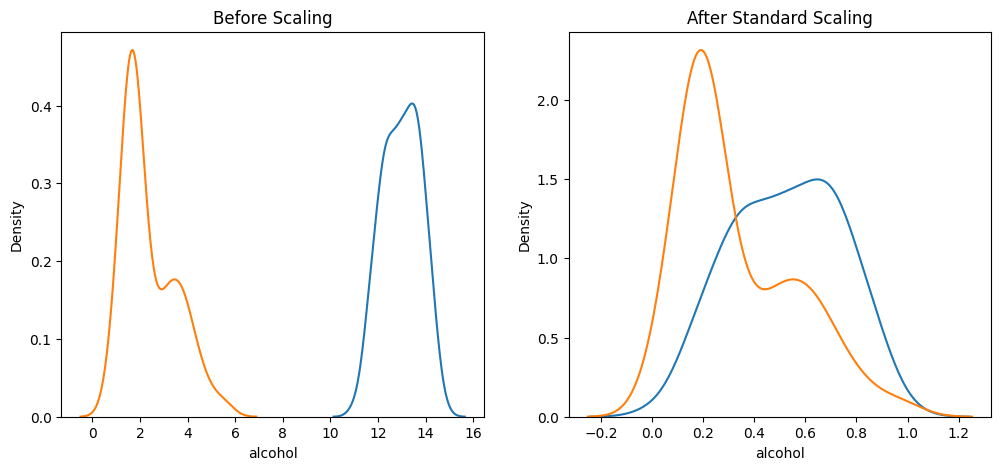

In [13]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['alcohol'], ax=ax1)
sns.kdeplot(x_train['malic acid'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(x_train_scaled['alcohol'], ax=ax2)
sns.kdeplot(x_train_scaled['malic acid'], ax=ax2)
plt.show()